# House Price Prediction

This project is about predicting house prices in India using machine learning. The dataset has details like location, carpet area, BHK, bathrooms, furnishing etc. I'll clean the data, do some visualizations, and then try Linear Regression and Random Forest to see which one works better.

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Loading and Exploring the Dataset

In [ ]:
df = pd.read_csv("house_prices.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Description:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  o

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

Missing values in each column:

                   Missing Count  Percentage
Plot Area                 187531  100.000000
Dimensions                187531  100.000000
Society                   109678   58.485264
Super Area                107685   57.422506
Car Parking               103357   55.114621
overlooking                81436   43.425354
Carpet Area                80673   43.018488
facing                     70233   37.451408
Ownership                  65517   34.936624
Balcony                    48935   26.094352
Price (in rupees)          17665    9.419776
Floor                       7077    3.773776
Description                 3023    1.612000
Furnishing                  2897    1.544811
Bathroom                     828    0.441527
Status                       615    0.327946
Transaction                   83    0.044259


## Data Cleaning

The dataset is pretty messy — some columns are completely empty, the price column has text like "42 Lac" and "1.40 Cr" that needs converting, carpet area has "sqft" attached, and the BHK count is buried in the title. So I need to clean all of that up before doing anything.

In [ ]:
df['BHK'] = df['Title'].str.extract(r'(\d+)\s*BHK')
df['BHK'] = pd.to_numeric(df['BHK'], errors='coerce')
print("BHK value counts:")
print(df['BHK'].value_counts())

BHK value counts:
BHK
3.0     80848
2.0     75508
4.0     16600
1.0     12284
5.0      1183
6.0        98
10.0       43
7.0        22
8.0        17
9.0         7
Name: count, dtype: int64


In [6]:
# Step 3b: Convert Amount column to numeric (in Lakhs)
# "42 Lac" -> 42, "1.40 Cr" -> 140, "Ask Price" -> NaN

def convert_amount(val):
    """Convert amount string to numeric value in Lakhs"""
    try:
        val = str(val).strip()
        if 'Cr' in val:
            return float(val.replace('Cr', '').strip()) * 100  # 1 Cr = 100 Lac
        elif 'Lac' in val:
            return float(val.replace('Lac', '').strip())
        else:
            return np.nan
    except:
        return np.nan

df['Price_in_Lakhs'] = df['Amount(in rupees)'].apply(convert_amount)
print("Price in Lakhs - Sample values:")
print(df['Price_in_Lakhs'].head(10))
print(f"\nNull values in Price_in_Lakhs: {df['Price_in_Lakhs'].isnull().sum()}")

Price in Lakhs - Sample values:
0     42.0
1     98.0
2    140.0
3     25.0
4    160.0
5     45.0
6     16.5
7     60.0
8     60.0
9    160.0
Name: Price_in_Lakhs, dtype: float64

Null values in Price_in_Lakhs: 9684


In [7]:
# Step 3c: Clean Carpet Area column (remove 'sqft' and convert to numeric)
df['Carpet_Area_sqft'] = df['Carpet Area'].str.replace('sqft', '', regex=False).str.strip()
df['Carpet_Area_sqft'] = pd.to_numeric(df['Carpet_Area_sqft'], errors='coerce')
print("Carpet Area sample:")
print(df['Carpet_Area_sqft'].head(10))
print(f"\nNull values: {df['Carpet_Area_sqft'].isnull().sum()}")

Carpet Area sample:
0    500.0
1    473.0
2    779.0
3    530.0
4    635.0
5      NaN
6    550.0
7      NaN
8      NaN
9    900.0
Name: Carpet_Area_sqft, dtype: float64

Null values: 87103


In [8]:
# Step 3d: Clean Bathroom column
df['Bathroom'] = df['Bathroom'].replace('> 10', '10')
df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')
print("Bathroom value counts:")
print(df['Bathroom'].value_counts())

Bathroom value counts:
Bathroom
2.0     93007
3.0     55781
1.0     18654
4.0     15600
5.0      3343
6.0       209
10.0       49
7.0        35
8.0        14
9.0        11
Name: count, dtype: int64


In [9]:
# Step 3e: Drop unnecessary columns and keep only useful ones
# Dropping columns with too many nulls or text data that we don't need
columns_to_drop = ['Index', 'Title', 'Description', 'Amount(in rupees)', 
                   'Price (in rupees)', 'Carpet Area', 'Floor', 'facing', 
                   'overlooking', 'Society', 'Balcony', 'Car Parking', 
                   'Super Area', 'Dimensions', 'Plot Area', 'Ownership']

df = df.drop(columns=columns_to_drop)
print("Remaining columns:", list(df.columns))
print("Shape after dropping columns:", df.shape)
df.head()

Remaining columns: ['location', 'Status', 'Transaction', 'Furnishing', 'Bathroom', 'BHK', 'Price_in_Lakhs', 'Carpet_Area_sqft']
Shape after dropping columns: (187531, 8)


,location,Status,Transaction,Furnishing,Bathroom,BHK,Price_in_Lakhs,Carpet_Area_sqft
0,thane,Ready to Move,Resale,Unfurnished,1.0,1.0,42.0,500.0
1,thane,Ready to Move,Resale,Semi-Furnished,2.0,2.0,98.0,473.0
2,thane,Ready to Move,Resale,Unfurnished,2.0,2.0,140.0,779.0
3,thane,Ready to Move,Resale,Unfurnished,1.0,1.0,25.0,530.0
4,thane,Ready to Move,Resale,Unfurnished,2.0,2.0,160.0,635.0


In [10]:
# Step 3f: Drop rows with missing values in important columns
print(f"Shape before dropping nulls: {df.shape}")

# Drop rows where our target variable (Price_in_Lakhs) is null
df = df.dropna(subset=['Price_in_Lakhs'])
print(f"After dropping null prices: {df.shape}")

# Drop rows where BHK is null
df = df.dropna(subset=['BHK'])
print(f"After dropping null BHK: {df.shape}")

# Drop rows where Carpet Area is null
df = df.dropna(subset=['Carpet_Area_sqft'])
print(f"After dropping null Carpet Area: {df.shape}")

# Fill remaining missing values
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Transaction'] = df['Transaction'].fillna(df['Transaction'].mode()[0])
df['Furnishing'] = df['Furnishing'].fillna('Unfurnished')
df['Status'] = df['Status'].fillna('Ready to Move')

print(f"\nFinal shape: {df.shape}")
print(f"\nRemaining null values:\n{df.isnull().sum()}")

Shape before dropping nulls: (187531, 8)
After dropping null prices: (177847, 8)
After dropping null BHK: (177528, 8)
After dropping null Carpet Area: (95843, 8)

Final shape: (95843, 8)

Remaining null values:
location            0
Status              0
Transaction         0
Furnishing          0
Bathroom            0
BHK                 0
Price_in_Lakhs      0
Carpet_Area_sqft    0
dtype: int64


In [11]:
# Step 3g: Remove outliers - houses with unreasonable prices
print("Before removing outliers:", df.shape)

# Remove extremely cheap or expensive houses
df = df[(df['Price_in_Lakhs'] > 1) & (df['Price_in_Lakhs'] < 5000)]

# Remove houses with unreasonable carpet area
df = df[(df['Carpet_Area_sqft'] > 100) & (df['Carpet_Area_sqft'] < 10000)]

# Keep only common BHK types (1-5)
df = df[df['BHK'] <= 5]

print("After removing outliers:", df.shape)
df.head()

Before removing outliers: (95843, 8)
After removing outliers: (94809, 8)


,location,Status,Transaction,Furnishing,Bathroom,BHK,Price_in_Lakhs,Carpet_Area_sqft
0,thane,Ready to Move,Resale,Unfurnished,1.0,1.0,42.0,500.0
1,thane,Ready to Move,Resale,Semi-Furnished,2.0,2.0,98.0,473.0
2,thane,Ready to Move,Resale,Unfurnished,2.0,2.0,140.0,779.0
3,thane,Ready to Move,Resale,Unfurnished,1.0,1.0,25.0,530.0
4,thane,Ready to Move,Resale,Unfurnished,2.0,2.0,160.0,635.0


## EDA

Some basic plots to understand the data — price distribution, how BHK and carpet area relate to price, which locations are expensive, etc.

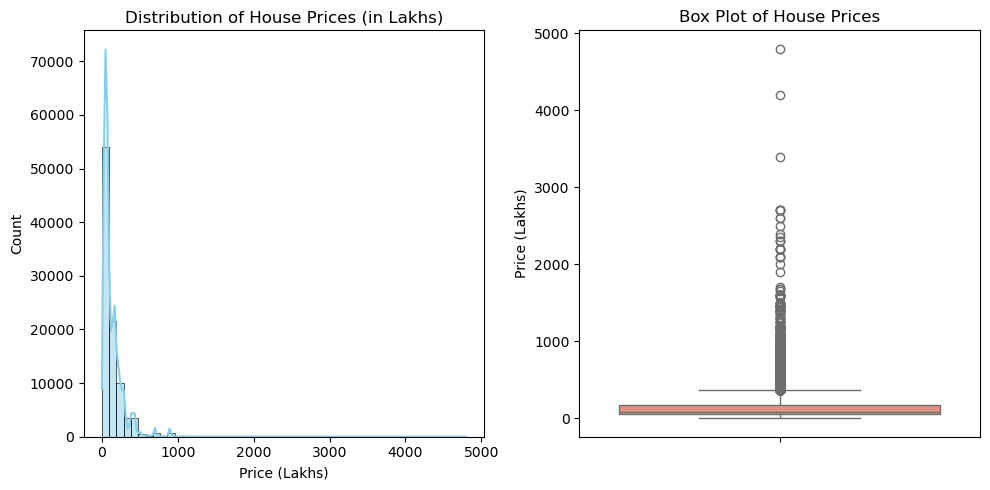

In [12]:
# Distribution of House Prices
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of House Prices (in Lakhs)')
plt.xlabel('Price (Lakhs)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price_in_Lakhs'], color='salmon')
plt.title('Box Plot of House Prices')
plt.ylabel('Price (Lakhs)')

plt.tight_layout()
plt.show()

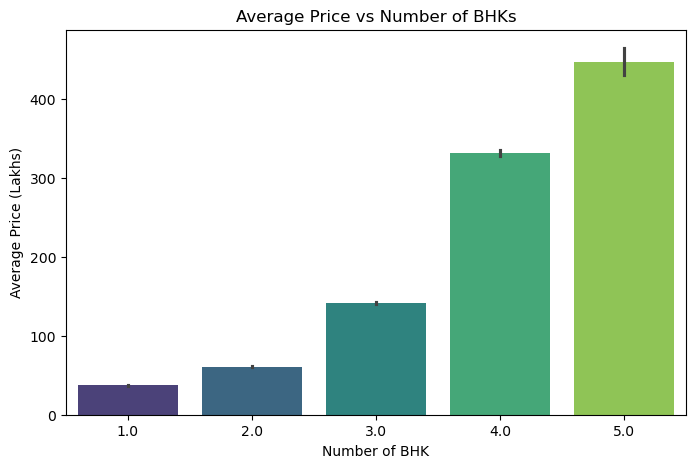

In [13]:
# Price vs BHK
plt.figure(figsize=(8, 5))
sns.barplot(x='BHK', y='Price_in_Lakhs', data=df, palette='viridis')
plt.title('Average Price vs Number of BHKs')
plt.xlabel('Number of BHK')
plt.ylabel('Average Price (Lakhs)')
plt.show()

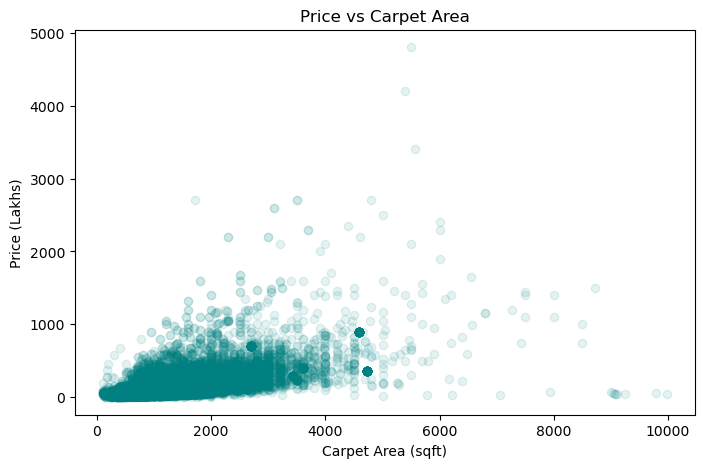

In [14]:
# Price vs Carpet Area (scatter plot)
plt.figure(figsize=(8, 5))
plt.scatter(df['Carpet_Area_sqft'], df['Price_in_Lakhs'], alpha=0.1, color='teal')
plt.title('Price vs Carpet Area')
plt.xlabel('Carpet Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.show()

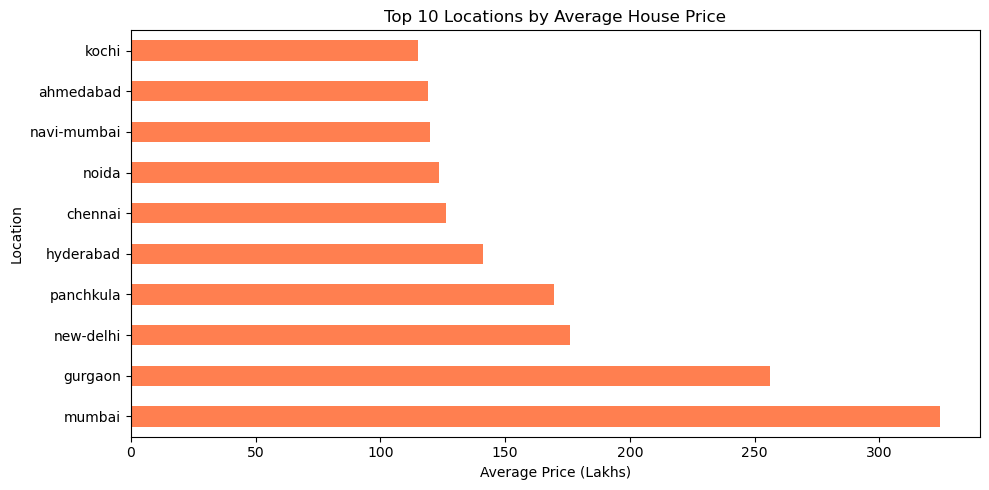

In [15]:
# Top 10 locations by average price
top_locations = df.groupby('location')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
top_locations.plot(kind='barh', color='coral')
plt.title('Top 10 Locations by Average House Price')
plt.xlabel('Average Price (Lakhs)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

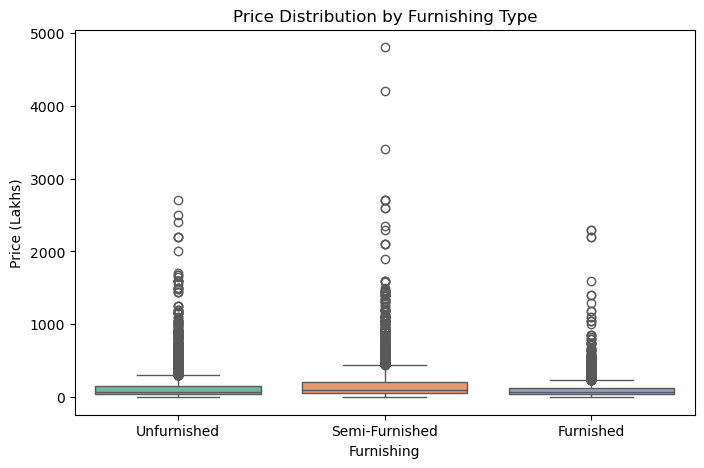

In [16]:
# Furnishing vs Price
plt.figure(figsize=(8, 5))
sns.boxplot(x='Furnishing', y='Price_in_Lakhs', data=df, palette='Set2')
plt.title('Price Distribution by Furnishing Type')
plt.xlabel('Furnishing')
plt.ylabel('Price (Lakhs)')
plt.show()

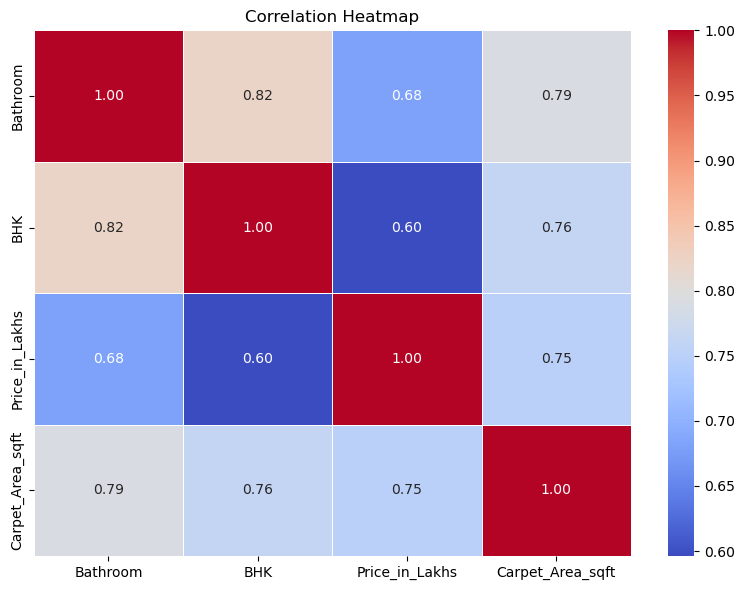

In [17]:
# Correlation Heatmap (for numeric columns)
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Feature Engineering

Converting categorical columns to numbers using LabelEncoder so the model can use them.

In [18]:
# Encode categorical variables using Label Encoding
le_location = LabelEncoder()
le_transaction = LabelEncoder()
le_furnishing = LabelEncoder()
le_status = LabelEncoder()

df['location_encoded'] = le_location.fit_transform(df['location'])
df['Transaction_encoded'] = le_transaction.fit_transform(df['Transaction'])
df['Furnishing_encoded'] = le_furnishing.fit_transform(df['Furnishing'])
df['Status_encoded'] = le_status.fit_transform(df['Status'])

print("Encoding done!")
print("\nLocation encoding sample:")
print(dict(zip(le_location.classes_[:5], le_location.transform(le_location.classes_[:5]))))
print(f"\nFurnishing mapping: {dict(zip(le_furnishing.classes_, le_furnishing.transform(le_furnishing.classes_)))}")
print(f"Transaction mapping: {dict(zip(le_transaction.classes_, le_transaction.transform(le_transaction.classes_)))}")

Encoding done!

Location encoding sample:
{'agra': np.int64(0), 'ahmadnagar': np.int64(1), 'ahmedabad': np.int64(2), 'allahabad': np.int64(3), 'aurangabad': np.int64(4)}

Furnishing mapping: {'Furnished': np.int64(0), 'Semi-Furnished': np.int64(1), 'Unfurnished': np.int64(2)}
Transaction mapping: {'New Property': np.int64(0), 'Other': np.int64(1), 'Rent/Lease': np.int64(2), 'Resale': np.int64(3)}


In [19]:
# Select features (X) and target variable (y)
features = ['BHK', 'Carpet_Area_sqft', 'Bathroom', 'location_encoded', 
            'Transaction_encoded', 'Furnishing_encoded', 'Status_encoded']

X = df[features]
y = df['Price_in_Lakhs']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures used:")
for f in features:
    print(f"  - {f}")
X.head()

Features (X) shape: (94809, 7)
Target (y) shape: (94809,)

Features used:
  - BHK
  - Carpet_Area_sqft
  - Bathroom
  - location_encoded
  - Transaction_encoded
  - Furnishing_encoded
  - Status_encoded


,BHK,Carpet_Area_sqft,Bathroom,location_encoded,Transaction_encoded,Furnishing_encoded,Status_encoded
0,1.0,500.0,1.0,67,3,2,0
1,2.0,473.0,2.0,67,3,1,0
2,2.0,779.0,2.0,67,3,2,0
3,1.0,530.0,1.0,67,3,2,0
4,2.0,635.0,2.0,67,3,2,0


## Train-Test Split

Splitting into 80% training and 20% testing.

In [20]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 75847 samples
Testing set size: 18962 samples


## Model Training

Training two models — Linear Regression as a simple baseline, and Random Forest which should do better. Evaluating with MAE, RMSE, and R² score.

In [21]:
# Model 1: Linear Regression
print("=" * 50)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 50)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print(f"\nMean Absolute Error (MAE): {lr_mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.2f} Lakhs")
print(f"R² Score: {lr_r2:.4f}")
print(f"\nInterpretation: The model explains {lr_r2*100:.2f}% of the variance in house prices.")

MODEL 1: LINEAR REGRESSION

Mean Absolute Error (MAE): 54.20 Lakhs
Root Mean Squared Error (RMSE): 96.57 Lakhs
R² Score: 0.5728

Interpretation: The model explains 57.28% of the variance in house prices.


In [22]:
# Model 2: Random Forest Regressor
print("=" * 50)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 50)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"\nMean Absolute Error (MAE): {rf_mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f} Lakhs")
print(f"R² Score: {rf_r2:.4f}")
print(f"\nInterpretation: The model explains {rf_r2*100:.2f}% of the variance in house prices.")

MODEL 2: RANDOM FOREST REGRESSOR

Mean Absolute Error (MAE): 13.34 Lakhs
Root Mean Squared Error (RMSE): 59.63 Lakhs
R² Score: 0.8371

Interpretation: The model explains 83.71% of the variance in house prices.

Mean Absolute Error (MAE): 13.34 Lakhs
Root Mean Squared Error (RMSE): 59.63 Lakhs
R² Score: 0.8371

Interpretation: The model explains 83.71% of the variance in house prices.


## Model Comparison

Comparing both models side by side to see which performed better.

Model Comparison:
            Model  MAE (Lakhs)  RMSE (Lakhs)  R² Score
Linear Regression    54.200699     96.566532  0.572801
    Random Forest    13.341020     59.634781  0.837079


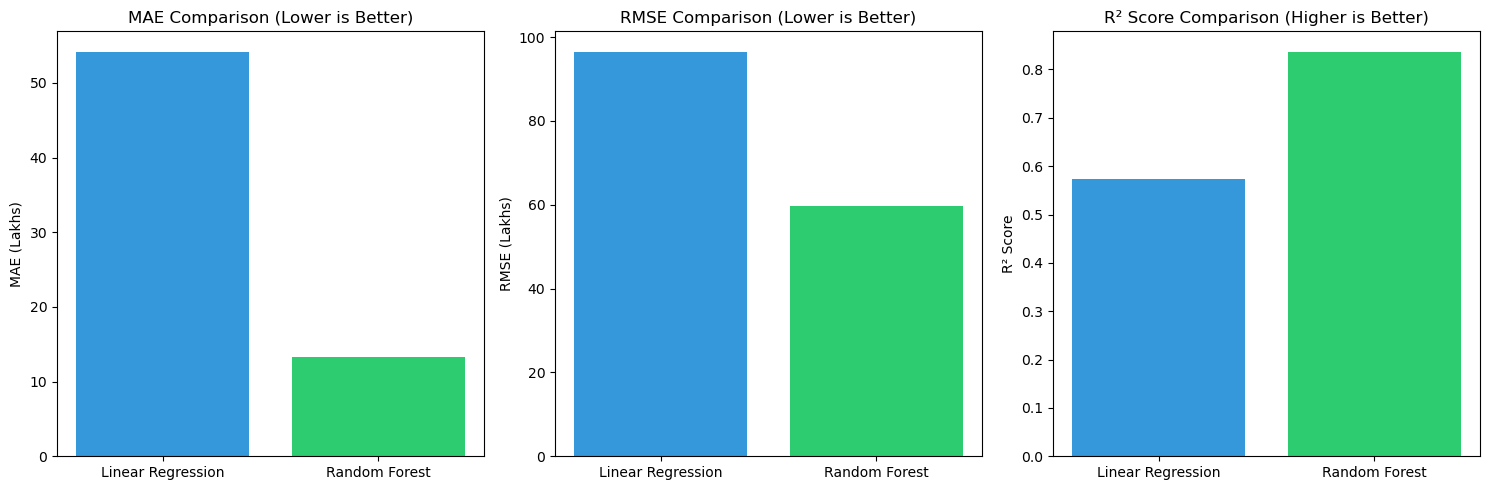

In [23]:
# Compare both models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Lakhs)': [lr_mae, rf_mae],
    'RMSE (Lakhs)': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})
print("Model Comparison:")
print(comparison.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE comparison
axes[0].bar(comparison['Model'], comparison['MAE (Lakhs)'], color=['#3498db', '#2ecc71'])
axes[0].set_title('MAE Comparison (Lower is Better)')
axes[0].set_ylabel('MAE (Lakhs)')

# RMSE comparison
axes[1].bar(comparison['Model'], comparison['RMSE (Lakhs)'], color=['#3498db', '#2ecc71'])
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE (Lakhs)')

# R² comparison
axes[2].bar(comparison['Model'], comparison['R² Score'], color=['#3498db', '#2ecc71'])
axes[2].set_title('R² Score Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()

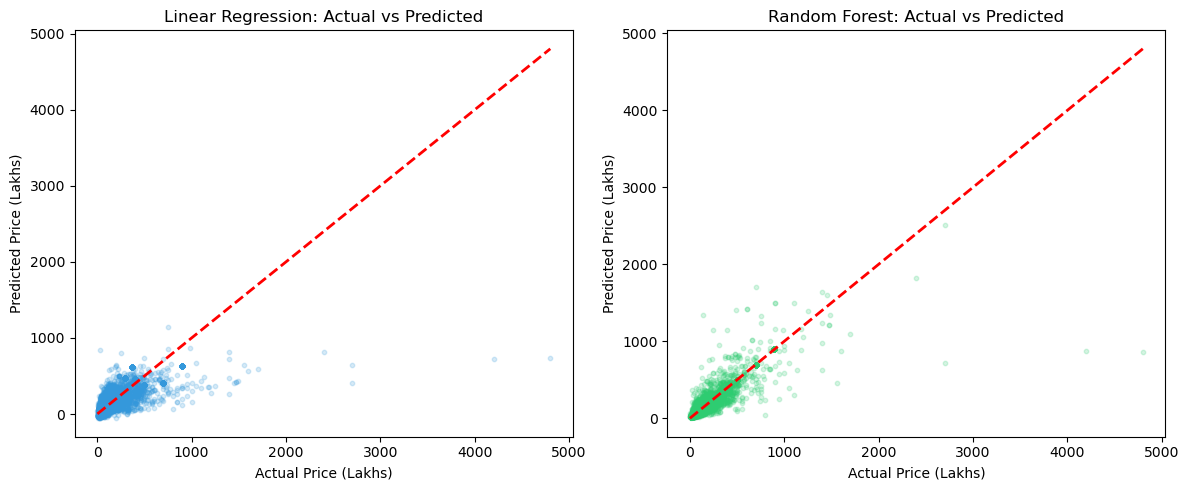

In [24]:
# Actual vs Predicted scatter plot (using the best model)
plt.figure(figsize=(12, 5))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.2, color='#3498db', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')

# Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.2, color='#2ecc71', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')

plt.tight_layout()
plt.show()

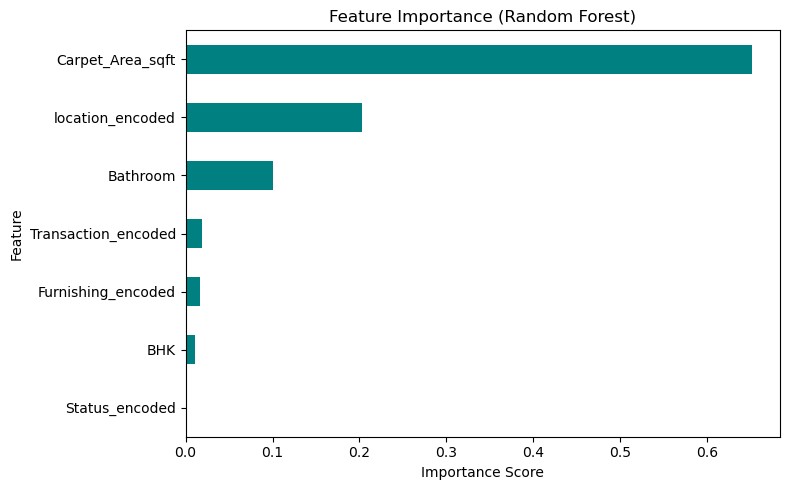

In [25]:
# Feature Importance from Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=features)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Saving the Model

Saving the trained Random Forest model and the label encoders using pickle so I can load them later without retraining.

In [ ]:
import pickle

# Save the Random Forest model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the label encoders
encoders = {
    'le_location': le_location,
    'le_transaction': le_transaction,
    'le_furnishing': le_furnishing,
    'le_status': le_status,
    'features': features
}

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Model saved as rf_model.pkl")
print("Encoders saved as encoders.pkl")